In [1]:
import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math
import scipy

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev, median
from pathlib import Path

##########################################################
# Initialize parameters  
##########################################################

# test file for linearity tests
#filename = "../data/packet-warm_ped_150cycles_60s_7tiles_2026_1_13.hdf5"

# set1-7 warm pedestal datafiles before and after disabling hot channels
#filename = "../results/set1-7/data/packet-warm_ped_150cycles_480s_7tiles_2026_1_6.hdf5"
#filename = "../results/set1-7/data/packet-warm_ped_150cycles_480s_7tiles_disable-hotchan-link_2026_1_9.hdf5"
filename = "../data/packet-warm_ped_dropped_pkts.hdf5"

# data file from 5-tile cold pedestal run
#filename = "/data/v3/10x16/20251028_5tile_test/cold/packet-cold_pedestal_4tiles-2025_10_28_17_25_23_PDT.h5"

# tiles tested in this filename or the subset of tiles on which you wish to check tally 
tiles = [1,2,3,4,5,6,7]

# serial numbers for set 1-7
chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101' ]
ntiles = 7

# Setting verbose = True will print out various pieces of chip-level or packet-level information 
verbose = False

# the following values are just being initialized to zero
nenabled_chips = 0
ig = 1 #this script can only run 1 io_group (and 1 tile) at a time
files = []
first_tile = True
kurtosis_list, kurtosis_percent_list = [], []
verbose = False

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
# determine pedestal stability through time by measuring the difference between the mean dataword for all pkts (roughly 3.5k
# per channel for a 480s run) and the mean dataword for every 100 pkts. 
def word_stability(mean_all_pkts, pkts, tile, chip, chan):

    global mean_diff, n_segments

    # initialize
    graph_datawords = False
    segment = 0
    less_stable_means = []
    
    # divide the pkts into 100 pkt segments
    n_segments = int(len(pkts)/100)
    
    # calculate the mean for each segment and determine if its stable
    for s in range(n_segments):

        min_pkt = segment*100
        max_pkt = min_pkt+100

        mean_segment = np.mean( pkts[min_pkt:max_pkt] )
        
        # calculate the difference in the mean for this segment and the mean for all packets
        diff = int(abs(mean_all_pkts - mean_segment))
        
        mean_diff.append(diff)

        # if the mean is off by more than 1 dataword flag this difference for printing and graphing
        if diff > 1:
            less_stable_means.append(int(mean_segment))
            graph_datawords = True    

        segment +=1

    if graph_datawords:

        print(f"\nTile-Chip-Channel {tile}-{chip}-{chan}: {mean_all_pkts:.0f}: {less_stable_means} mean of all pkts: less stable means")
        
        fig, ax = plt.subplots(1,1,figsize=(6, 3))
        plt.title(f"Tile-Chip-Channel {tile}-{chip}-{chan} Pedestal Datawords\nUnstable Means = {mean_all_pkts:.0f}, {less_stable_means}\nBenchtop Test of v3a Tile #{tile} ({chip_serial_number})")    
        ax.plot(pkts, color = 'g')
        ax.set_xlabel(f'Packet Number')
        #ax.set_yscale('log') 
        ax.set_ylabel(f'Dataword')        

    return
    

In [4]:
def skewness(data, chip, chan):
    """
    Calculate sample skewness (Fisher-Pearson).
    """
    data = np.array(data, dtype=float)
    n = len(data)
    if n < 3:
        raise ValueError(f"At least 3 data points required for skewness. Channel {chip}-{chan} only had {n}.")
    
    mean = np.mean(data)
    std_dev = np.std(data, ddof=1)  
    m3 = np.mean((data - mean) ** 3)
    
    # Fisher-Pearson coefficient of skewness
    if n > 3 and std_dev > 0:
        skew = (np.sqrt(n * (n - 1)) / (n - 2)) * (m3 / (std_dev ** 3))
    else:
        print(f'\nProblem calculating skew Chip-Channel {chip}-{chan}. Stdev = {std_dev}, # pkts {n}')
        skew = 0        

    #print(f"Chan {chip}-{chan} skew = {skew}")
    
    return skew

def kurtosis(data, chip, chan):
    """
    Calculate sample excess kurtosis (Fisher definition).
    """

    global kurtosis_list, verbose
    
    data = np.array(data, dtype=float)
    n = len(data)
    if n < 4:
        raise ValueError(f"At least 4 data points are required for kurtosis. Channel {chip}-{chan} only had {n}")
    
    mean = np.mean(data)
    std_dev = np.std(data, ddof=1)
    m4 = np.mean((data - mean) ** 4)
    
    # Excess kurtosis (subtract 3 to make normal distribution = 0)
    if n > 4 and std_dev > 0:
        #kurt = (n * (n + 1) * m4 / (std_dev ** 4) - 3 * (n - 1) ** 2) / ((n - 1) * (n - 2) * (n - 3))
        kurt = scipy.stats.kurtosis(data, axis = 0, fisher = True, bias = True)
    else:
        print(f'Problem calculating kurtosis Chip-Channel {chip}-{chan}. Stdev = {std_dev}, # pkts {len(data)}')
        kurt = 0        

    if kurt > 2 and verbose:
        print(f"Channel {chip}-{chan} kurtosis > 0.02 ({kurt})")

        fig, ax = plt.subplots(1,1,figsize=(6, 3))
        plt.title(f"Tile-Chip-Channel {tile}-{chip}-{chan} Pedestal Datawords (Kurtosis {kurt:.2f})\nBenchtop Test of v3a Tile #{tile} ({chip_serial_number})")    
        ax.plot(data, color = 'm')
        ax.set_xlabel(f'Packet Number')
        #ax.set_yscale('log') 
        ax.set_ylabel(f'Dataword')          
    
    kurtosis_list.append(kurt)
    
    return kurt

In [5]:
def get_data(filename, tile, ig):
    
    global data_pkts, npkts_mode, npkts_mode_chan, kurtosis_list
    global chip_serial_number, first_tile, mean_diff, n_segments, kurtosis_percent_list
    
    data_chips, ndata_by_chip_list, ndata_by_channel_list, npkts = [], [], [], 0
    ndata_by_chip    = [0 for chip in range(256)]
    ndata_by_channel = [[0 for chan in range(64)] for chip in range(256)]
    
    bad_std, bad_mean, high_skew = 0, 0, 0
    bad_std_list, bad_mean_list, high_skew_list, high_kurtosis_list = [], [], [], []
    mean_adc_list, std_adc_list, skew_adc_list, kurtosis_adc_list = [], [], [], []
    unique_chips  = []
    mean_diff = []
    misnumbered_chips = False
    wrong_ioch_chip = False
    debug_count = 0

    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    unixtime = f['packets'][:]['timestamp'][f['packets']
                                            [:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)
    
    # create arrays of data packets
    data_mask     = f['packets'][:]['packet_type']  == 1
    data_pkts     = packets[data_mask]

    # identify io_channels with data packets in this data file
    unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))
    unique_io_channels = sorted(unique_io_channels)

    # print out run statistics for the file
    if first_tile:
        npkts         = len(data_pkts) 
        print(f"\t{npkts:,} data packets for tile {tile} arriving at an average rate of {npkts/livetime:.0f} pkts/s over {livetime}s of data taking") 
        print(f"\tIO_channels in file: \n\t{[int(x) for x in unique_io_channels]}")
        first_tile = False

    # get a list of the io_channels that could be enabled for a given tile, and then determine which
    # ones were enabled
    io_channel_ids = get_io_channels(tile)
    enabled_io_channels = list(set(io_channel_ids) & set(unique_io_channels))
    
    print(f"\n\n############################ Checking Tile {tile} ###################################")
    print(f'Run Statistics for Tile {tile}:')    
    print(f'\tio_channels enabled for tile {tile}: {enabled_io_channels}')
    
    # mask for the chosen tile
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]

    # identify chips on this tile with data packets
    unique_chips = list(dict.fromkeys(data_pkts['chip_id'][:]))    
    
    npkts = len(data_pkts) 

    if npkts ==0: 
        print(f'There are no data packets for tile {tile}')        
        return
    
#########################################################
# identify misnumbered chips, out of range adc datawords
##########################################################
    
    data_chips = data_pkts['chip_id'][:]
    data_fifo  = data_pkts['shared_fifo'][:]
    nfifo_full = data_fifo.tolist().count(3)

    #print(f'Tile {tile}: {nfifo_full} packets registered shared FIFO full')
    
    unique_chips = list(dict.fromkeys(data_chips))

    print(f'\t{len(unique_chips)} chips were recorded from Tile {tile}')    
    
    for chip in range(11,171):

        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]

        chip_ioch  = chip_pkts['io_channel'][:]
        chip_chans = chip_pkts['channel_id'][:]
        chip_adc   = chip_pkts['dataword'][:]

        unique_iochs = list(dict.fromkeys(chip_ioch))
        
        # create list used to determine mode of # pkts per chip
        ndata_by_chip[chip] = len(chip_pkts)
        ndata_by_chip_list.append(ndata_by_chip[chip])
        
        mode_adc_chip = mode(chip_adc)

        high_kurtosis = 0
        
        # determine various channel attributes (# packets, mean adc, stdev adc, skew, kurtosis)
        for chan in range(64):
            chan_mask = chip_pkts['channel_id'] == chan
            chan_pkts = chip_pkts[chan_mask]
            chan_adc  = chan_pkts['dataword']

            # count the # of packets by channel
            npkt = len(chan_pkts)
            ndata_by_channel[chip][chan] = npkt
            ndata_by_channel_list.append(npkt)

            if npkt==0:
                continue
            
            # remove zero datawords
            non_zero_chan_adc = chan_adc[chan_adc != 0]

            # calculate acd mean and stdev. Identify channels with means or stdev outside of acceptible ranges
            if len(non_zero_chan_adc) > 1:

                npkts_chan = len(non_zero_chan_adc)
                
                mean_adc = np.mean(non_zero_chan_adc.tolist())
                mean_adc_list.append(mean_adc)
                # the acceptible channel mean range is the chip's mean dataword +/- 50
                if mean_adc > mode_adc_chip + 50 or mean_adc < mode_adc_chip - 50:
                    bad_mean_list.append(str(f"{chip}-{chan}"))
                    bad_mean +=1

                std_adc = stdev(non_zero_chan_adc.tolist())
                std_adc_list.append(std_adc)
                # the acceptible stdev range is [0.01, 2]                
                if std_adc > 2 or std_adc < 0.01:
                    bad_std +=1
                    bad_std_list.append(str(f"{chip}-{chan}"))

                skew_adc, kurtosis_adc = 0, 0 
                try:
                    skew_adc = skewness(non_zero_chan_adc.tolist(), chip, chan)
                    skew_adc_list.append(skew_adc)
                except:
                    print(f'Problem calculating skew for chip-chan {chip}-{chan}, only {len(non_zero_chan_adc)} pkts')

                # an abs(skew) < 2 indicates datawords are distributed evenly around their mean
                if abs(skew_adc) > 2:
                    high_skew +=1
                    high_skew_list.append(str(f"{chip}-{chan}"))

                try:
                    kurtosis_adc = kurtosis(non_zero_chan_adc.tolist(), chip, chan)
                    kurtosis_adc_list.append(kurtosis_adc)
                except:
                    print(f'Problem calculating kurtosis for chip-chan {chip}-{chan}, only {len(non_zero_chan_adc)} pkts')
                    
                # kurtosis = 0 indicates the distributions have tails consistent with a normal distribution
                if abs(kurtosis_adc) > 2:
                    high_kurtosis +=1
                    #high_kurtosis_list.append(str(f"{chip}-{chan}"))

                # determine dataword stability through time by measuring the difference between the mean of all pkts (roughly 3.5k per channel
                # for a 480s run) and the mean for every 100 pkts. 
                word_stability(mean_adc, non_zero_chan_adc, tile, chip, chan)
            
            elif verbose:
                print(f"channel {chip}-{chan} had {len(non_zero_chan_adc)} non-zero packets")

        high_kurtosis_percent = 100 * high_kurtosis / 64

        kurtosis_percent_list.append(high_kurtosis_percent)
               
    npkts_mode = mode(ndata_by_chip_list)
    npkts_mode_chan = mode(ndata_by_channel_list)

    # look for channels with less than half the typical # of packets
    for chip in range(11,171):
        for chan in range(64):
            npkts = ndata_by_channel[chip][chan]
            if (npkts < npkts_mode_chan * 0.5):
                print(f"Chip-chan {chip}-{chan} only had {100*npkts/npkts_mode_chan:.0f}% of the typical number of packets") 

    mode_mean_tile = mode(mean_adc_list)
    mean_stdev_tile = mean(std_adc_list)

    print(f'\nTile {tile} most common # of packets in a chip {npkts_mode}, Most common # of packets in a channel {npkts_mode_chan}')    
    print(f'\n{bad_std} channels ({bad_std/10240:.4f}%) had adc stdev outside of range [.01, 2] on Tile {tile}: \n{bad_std} TOTAL: {bad_std_list}\n')
    print(f'\n{bad_mean} channels ({bad_mean/10240:.4f}%) had adc mean > mode +/- 50 on Tile {tile}: \n{bad_mean} TOTAL: {bad_mean_list}\n')
    print(f'\n{high_skew} channels ({high_skew/10240:.4f}%) had adc skew > 2 on Tile {tile}: \n{high_skew} TOTAL: {high_skew_list}\n')    
    print(f'\n{high_kurtosis} channels ({high_kurtosis/10240:.4f}%) had adc kurtosis > 2 on Tile {tile}: \n{high_kurtosis} TOTAL: {high_kurtosis_list}\n') 
    print(f'\n{ndata_by_channel_list.count(0)} channels had no packets\n')  
  
    fig, axis = plt.subplots(1,2, figsize=(10, 4))
    plt.suptitle(f'Tile #{tile} ({chip_serial_number}): Zoom into Distributions of Mean (left) & Stdev (right) Dataword by Channel\n{bad_mean} chans mean > mode +/- 50                       {bad_std} chans stdev ouside [.01,2]')

    axis[0].hist(mean_adc_list, bins = int(max(mean_adc_list)))
    axis[0].set_xlabel(f'Mean ADC Dataword (zoom into distribution)')
    axis[0].set_yscale('log')
    axis[0].set_xlim(mode_mean_tile -50, mode_mean_tile +50)
    axis[0].text(mode_mean_tile -40, 100, f'Mode = {mode_mean_tile:.0f}', color='red', style='italic')    
    axis[0].axvline(x = mode_mean_tile, color='r', linestyle='--')    
    axis[0].set_ylabel(f'Channel Count')            

    axis[1].hist(std_adc_list, bins = int(max(std_adc_list))*10)
    axis[1].set_xlabel(f'Stdev ADC Dataword')
    axis[1].set_xlim(0,5)
    axis[1].text(2, 100, f'Mean = {mean_stdev_tile:.1f}', color='red', style='italic')    
    axis[1].axvline(x = mean_stdev_tile, color='r', linestyle='--')      
    axis[1].set_ylabel(f'Channel Count')
    axis[1].set_yscale('log')
    plt.show                

    fig, axis = plt.subplots(1,3, figsize=(12, 4))
    plt.suptitle(f'Tile #{tile} ({chip_serial_number}): Pedestal Skew (left),           Kurtosis (middle),                      # Pkts by Channel (right)\n{high_skew} chans skew > 2\
                                  {high_kurtosis} chans kurtosis > 2                              {ndata_by_channel_list.count(0)} channels had 0 packets')
    
    axis[0].hist(skew_adc_list, color = 'c')
    #axis[0].set_title(f'ADC Dataword Skew by Channel (Mode {mode_mean_tile:.0f})\n{high_skew} channels had skew > 2\nBenchtop test of v3a Tile #{tile} ({chip_serial_number})')
    axis[0].set_xlabel(f'ADC Dataword Skew')
    axis[0].set_yscale('log')
    axis[0].axvline(x = -2, color='r', linestyle='--') 
    axis[0].axvline(x =  2, color='r', linestyle='--') 
    axis[0].set_ylabel(f'Channel Count')
    
    xmax = max(2.2, max(kurtosis_adc_list))
    
    axis[1].hist(kurtosis_adc_list, color = 'm', bins=1000)
    #axis[1].set_title(f'ADC Dataword Kurtosis by Channel (Mode {mode_mean_tile:.0f})\n{high_kurtosis} channels had kurtosis > .02\nBenchtop test of v3a Tile #{tile} ({chip_serial_number})')
    axis[1].set_xlabel(f'ADC Dataword Kurtosis')
    axis[1].set_xlim(0,10)
    axis[1].set_yscale('log')
    axis[1].axvline(x = 2, color='r', linestyle='--') 
    #axis[1].set_ylabel(f'Channel Count')    
    
    axis[2].hist(ndata_by_channel_list)
    #axis[2].set_title(f'# of Datawords by Channel\n{ndata_by_channel_list.count(0)} channels had no packets\nBenchtop test of v3a Tile #{tile} ({chip_serial_number})')
    axis[2].set_xlabel(f'# of Packets')
    axis[2].set_yscale('log')
    #axis[2].set_ylabel(f'Channel Count')
    plt.show 

    fig, ax = plt.subplots(1,1,figsize=(6, 3))
    plt.title(f"Difference in Mean_Word({npkts_chan} pkts) and Mean_Word({n_segments} segments of 100pkts)\nBenchtop Test of v3a Tile #{tile} ({chip_serial_number}")    
    ax.hist(mean_diff, color = 'g')
    ax.set_xlabel(f'Mean({npkts_chan} pkts) - Mean(100 pkts)')
    ax.set_yscale('log') 
    ax.set_ylabel(f'Instances per Channel in Tile {tile}')
    
    return 

In [6]:
def get_dropped_pkts(filename):

    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    
    # create arrays of config read packets
    read_mask     = f['packets'][:]['packet_type']  == 3
    config_pkts     = packets[read_mask]
    npkts         = len(config_pkts)   
    
    # prints out an array with the chip id and number of dropped packets
    chips = config_pkts['chip_id'][:]
    chip_ids = config_pkts['register_data'][:]
    dropped = np.column_stack((chips,chip_ids))
    print(f"Intentionally dropped packets for this file: {dropped}")

    return

Run Statistics for Data File ../data/packet-warm_ped_dropped_pkts.hdf5:
[]
	12,817,453 data packets for tile 1 arriving at an average rate of 106812 pkts/s over 120s of data taking
	IO_channels in file: 
	[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 19, 21, 22, 23, 25, 26, 27, 29, 30, 31, 33, 34, 35, 37, 38, 39]


############################ Checking Tile 1 ###################################
Run Statistics for Tile 1:
	io_channels enabled for tile 1: [1, 2, 3, 4]
	161 chips were recorded from Tile 1

Problem calculating skew Chip-Channel 40-30. Stdev = 0.0, # pkts 125
Problem calculating kurtosis Chip-Channel 40-30. Stdev = 0.0, # pkts 125

Problem calculating skew Chip-Channel 50-12. Stdev = 0.0, # pkts 125
Problem calculating kurtosis Chip-Channel 50-12. Stdev = 0.0, # pkts 125

Problem calculating skew Chip-Channel 50-13. Stdev = 0.0, # pkts 125
Problem calculating kurtosis Chip-Channel 50-13. Stdev = 0.0, # pkts 125

Problem calculating skew Chip-Channel 50-14. Stdev =

/tmp/ipykernel_2742489/3752710263.py:206: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axis = plt.subplots(1,3, figsize=(12, 4))


Text(0, 0.5, '# of Chips')

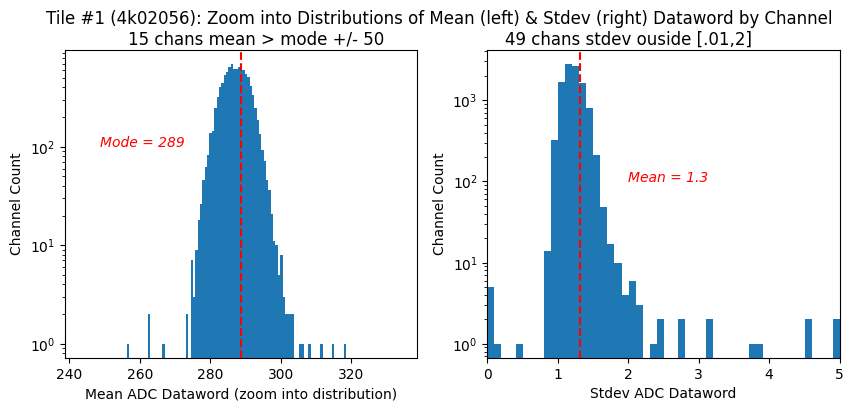

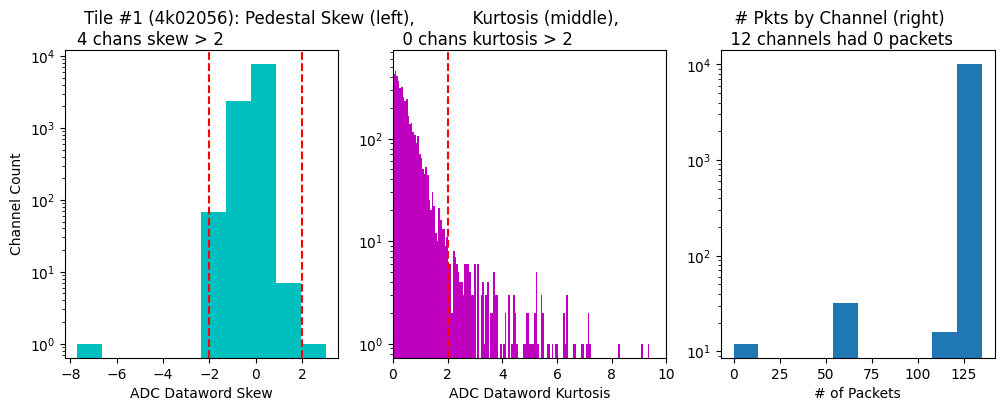

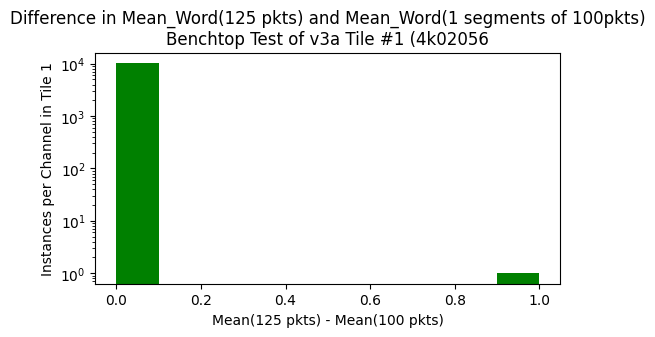

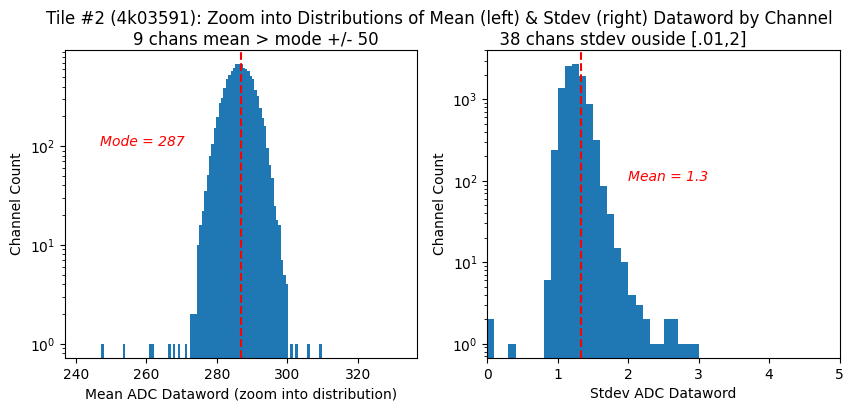

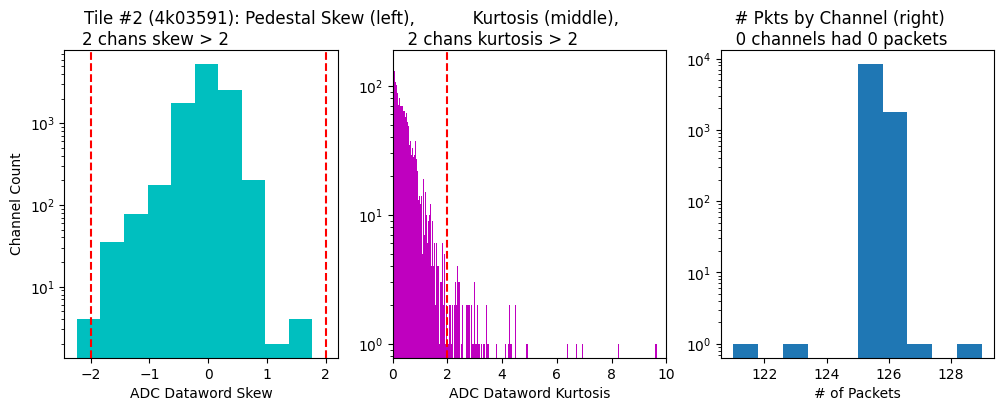

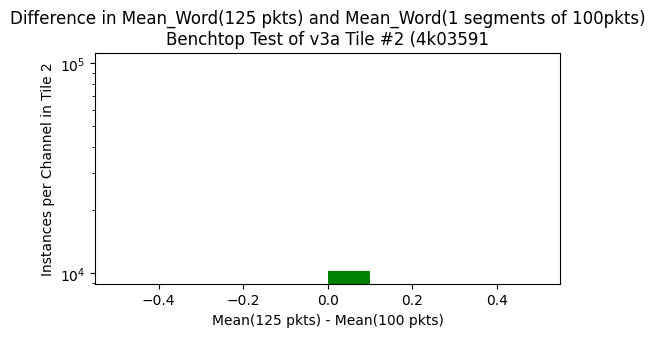

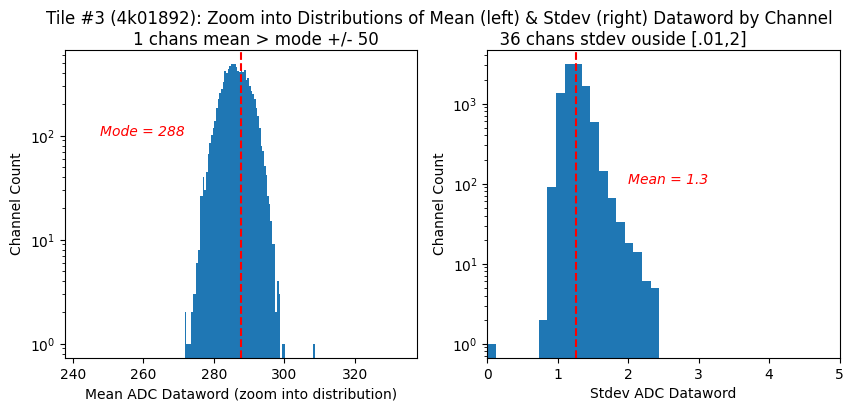

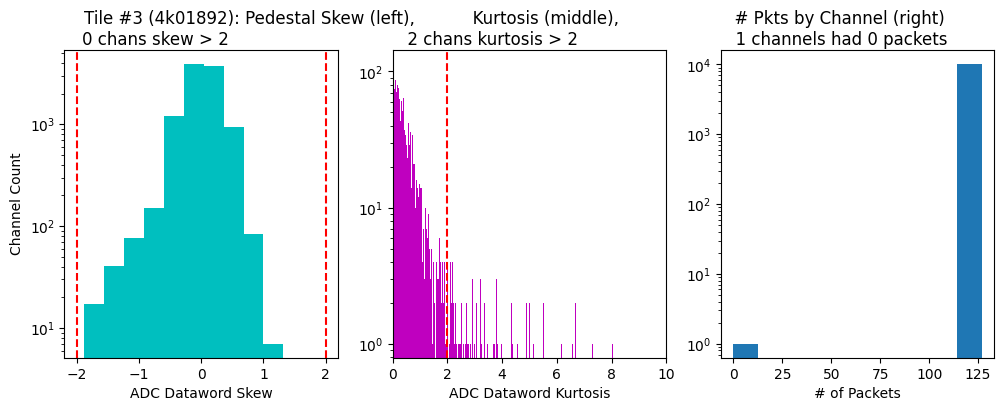

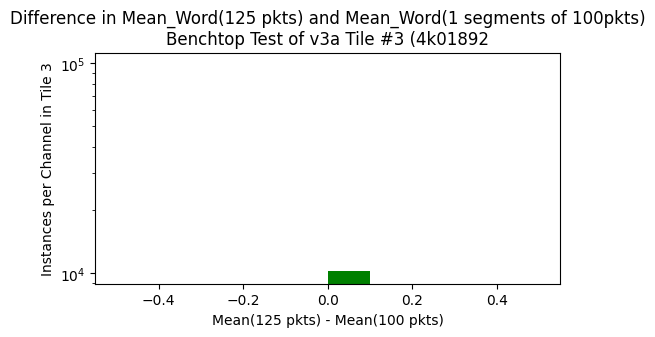

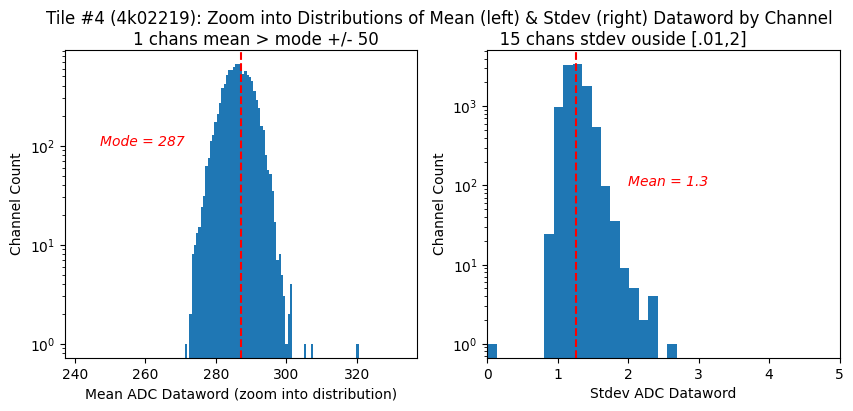

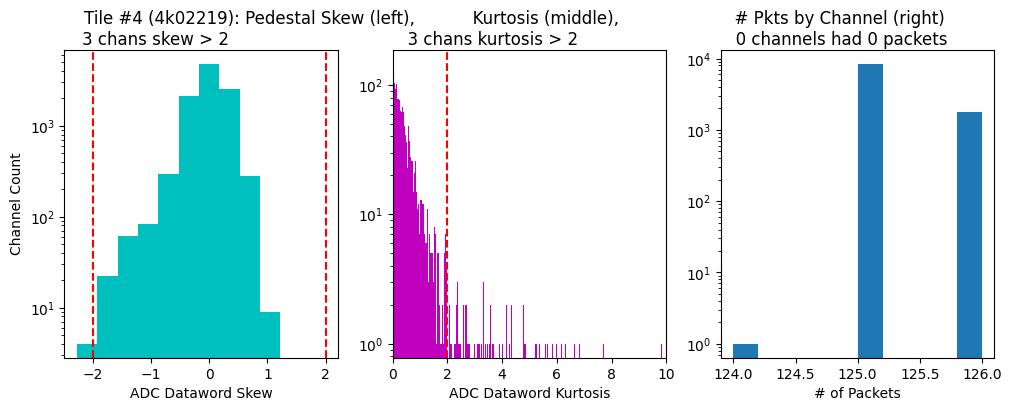

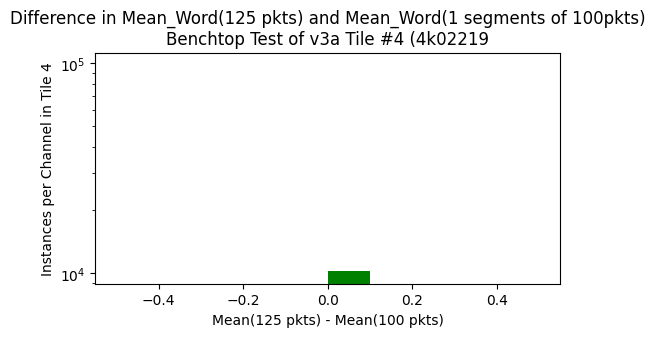

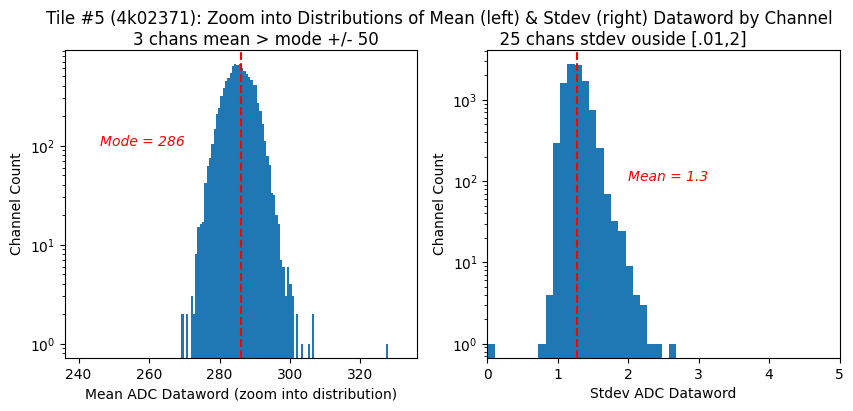

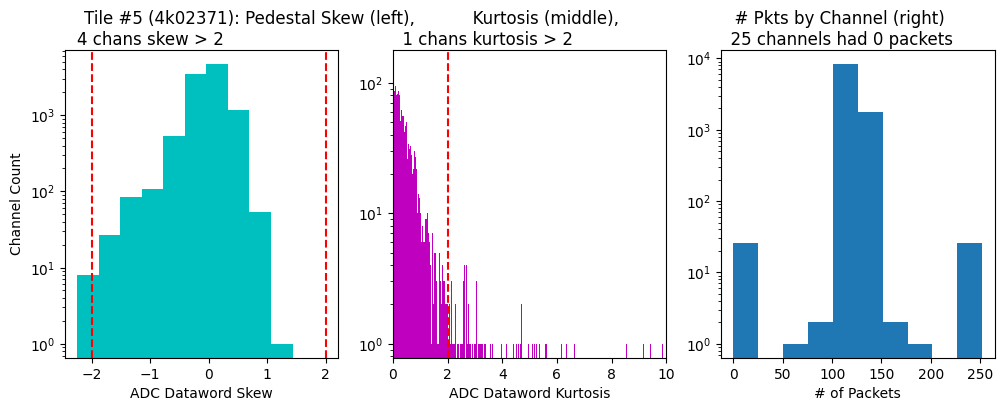

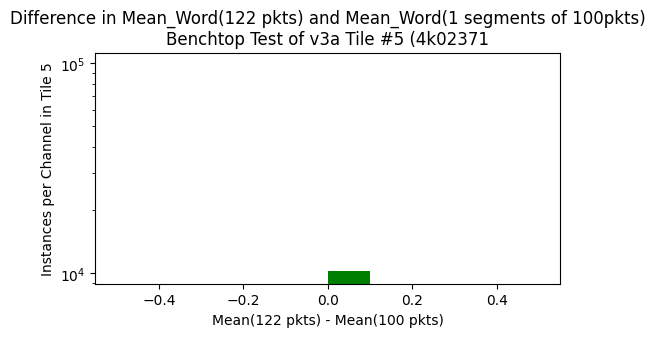

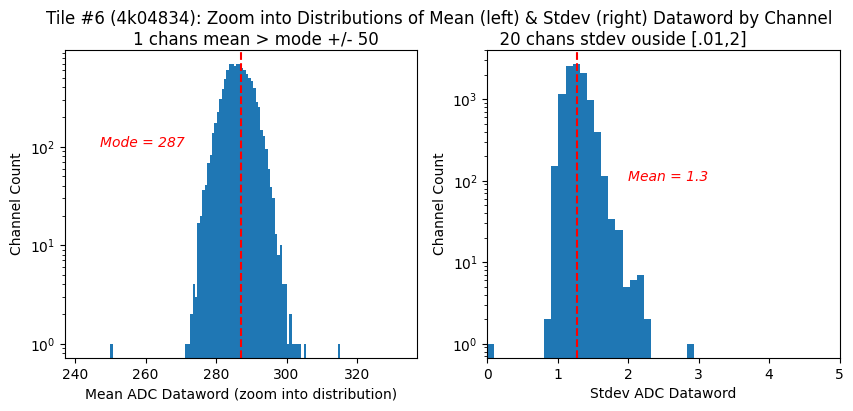

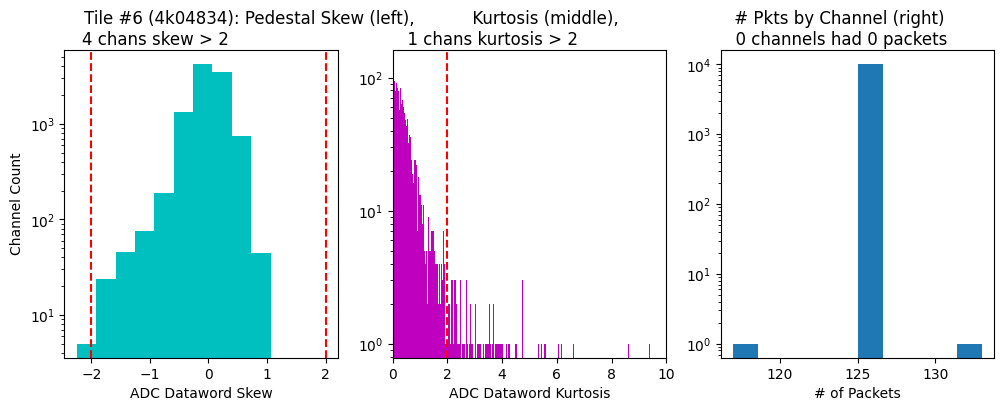

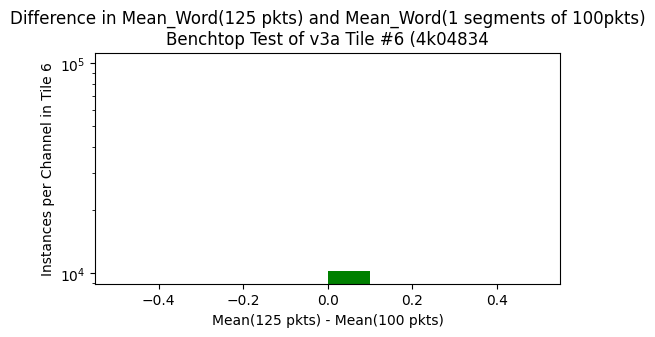

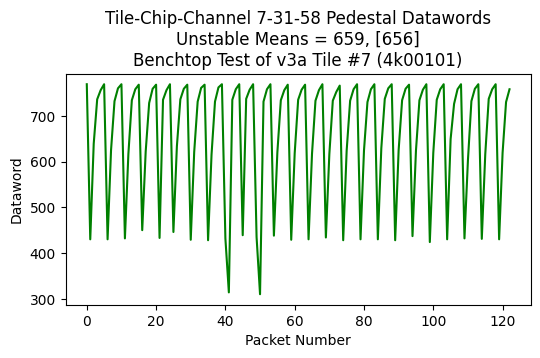

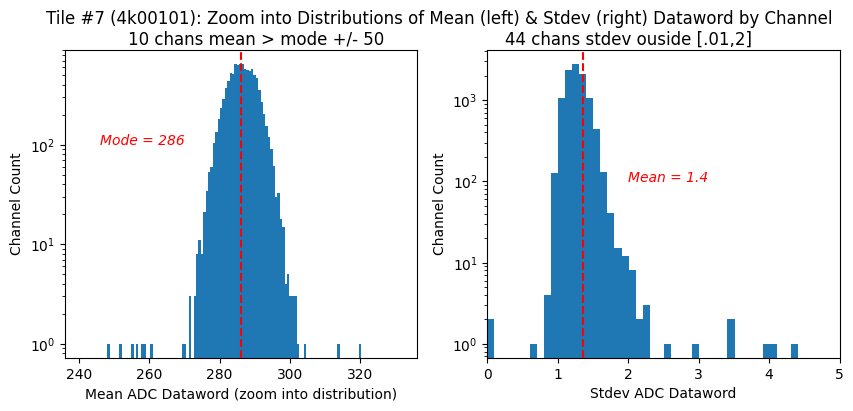

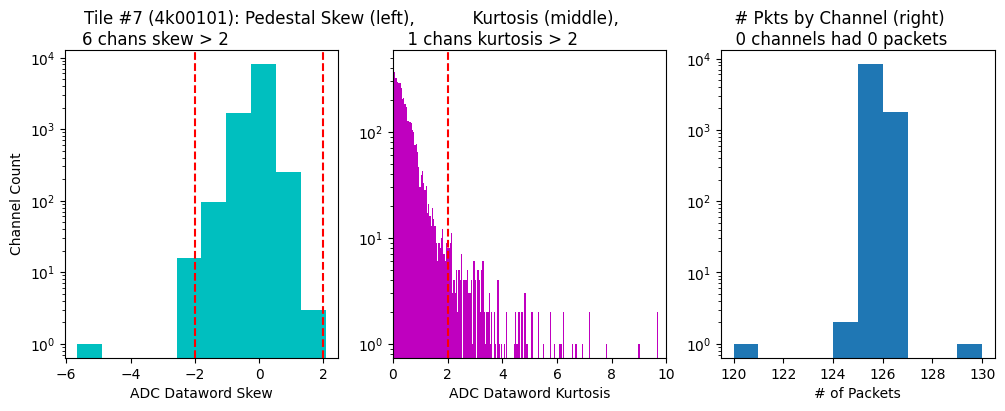

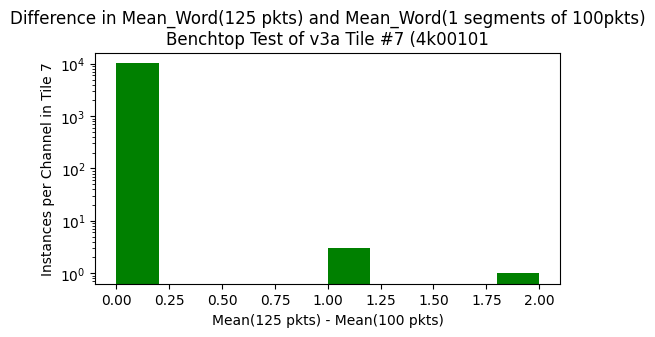

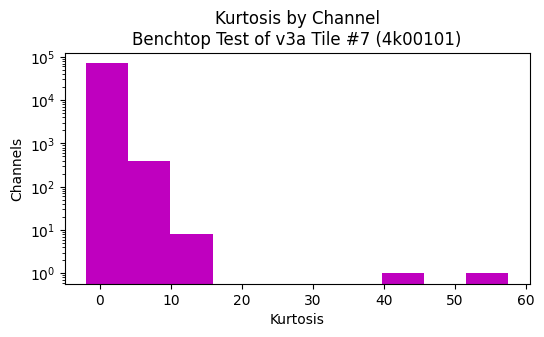

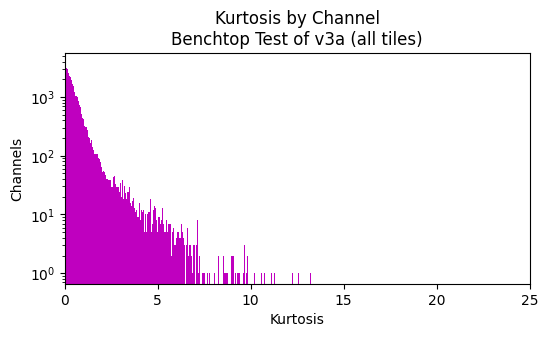

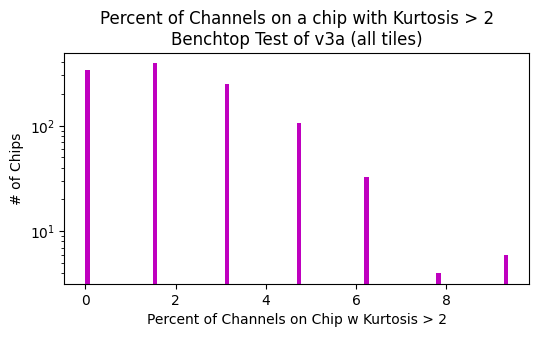

In [7]:
####################
# main
####################

print(f'Run Statistics for Data File {filename}:')

# read configuration packets with dropped packet totals
get_dropped_pkts(filename)

# get packets from pedestal run data file and check for various attributes
for tile in tiles:
    chip_serial_number = chip_serial_number_list[tile]
    get_data(filename, tile, ig)

fig, ax = plt.subplots(1,1,figsize=(6, 3))
plt.title(f"Kurtosis by Channel\nBenchtop Test of v3a Tile #{tile} ({chip_serial_number})")    
ax.hist(kurtosis_list, color = 'm')
ax.set_xlabel(f'Kurtosis')
ax.set_yscale('log') 
ax.set_ylabel(f'Channels')

fig, ax = plt.subplots(1,1,figsize=(6, 3))
plt.title(f"Kurtosis by Channel\nBenchtop Test of v3a (all tiles)")    
ax.hist(kurtosis_list, color = 'm', bins = 1000)
ax.set_xlim(0,25)
ax.set_xlabel(f'Kurtosis')
ax.set_yscale('log') 
ax.set_ylabel(f'Channels')

fig, ax = plt.subplots(1,1,figsize=(6, 3))
plt.title(f"Percent of Channels on a chip with Kurtosis > 2\nBenchtop Test of v3a (all tiles)")
ax.hist(kurtosis_percent_list, color = 'm', bins = 100)
ax.set_xlabel(f'Percent of Channels on Chip w Kurtosis > 2')
ax.set_yscale('log') 
ax.set_ylabel(f'# of Chips')